# **GUIDE**: RENDERER MODULE

This notebook is designed to provide a basic introduction to the rendering module. By the end, you'll be able to run your own simulation with your chosen parameters and interpret the results!

### **Setup**

This section walks you through the import and setup process.

**Steps**:

1. Identify and copy the path to the directory where main.py is located on your machine.
2. Paste the path in the cell below (`main_path`).
3. Run the cell to import the `renderer()` function.

In [3]:
import sys
import os

main_path = '../rendering/atm_renderer'

# Add the path to where main.py is located
sys.path.insert(0, os.path.abspath(main_path))

from main import renderer  # Import just the renderer function

### **Basic Simulation**

Let's start off by running a basic simulation with the default parameters. Run the cell below to get started!

(It may take a while to run the full simulation- don't be alarmed!)

VTK Version: 9.5.0
OpenGL2 Enabled: True
Drift angles shape: (5, 120)
Sample angles: [0.80783041 3.13705533 3.77932564 0.18025836 0.929447  ]
Simulation completed in 45.73 seconds.
Creating 2 videos using 4 workers...
Saved: output\default_sim\frame_incl0_t000.png


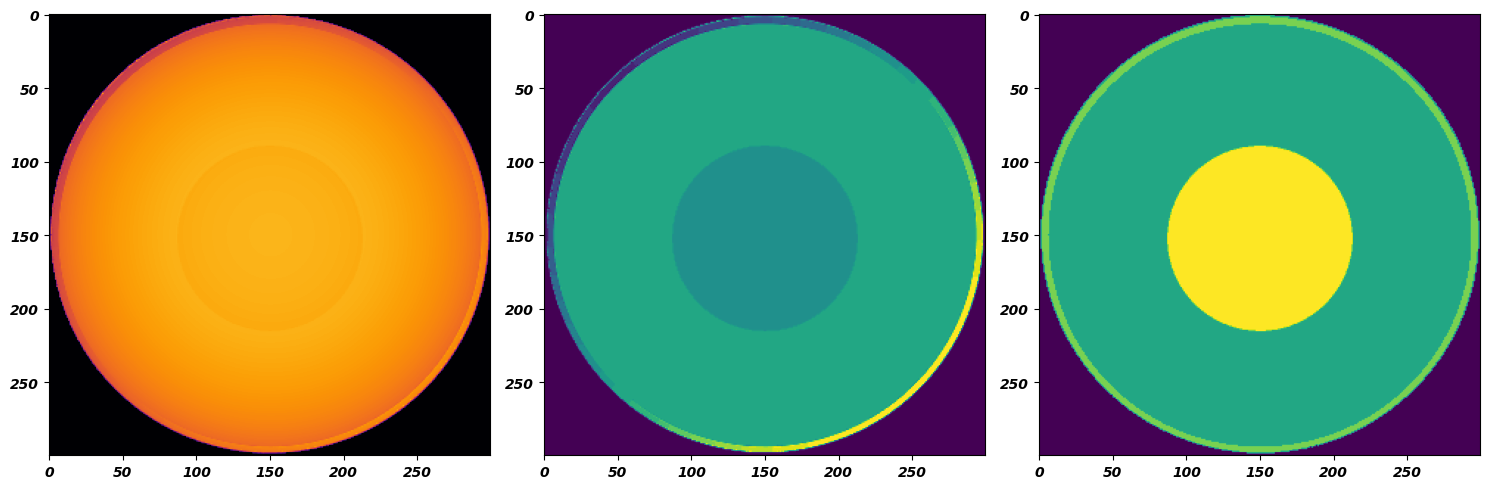

Saved: output\default_sim\frame_incl30_t000.png


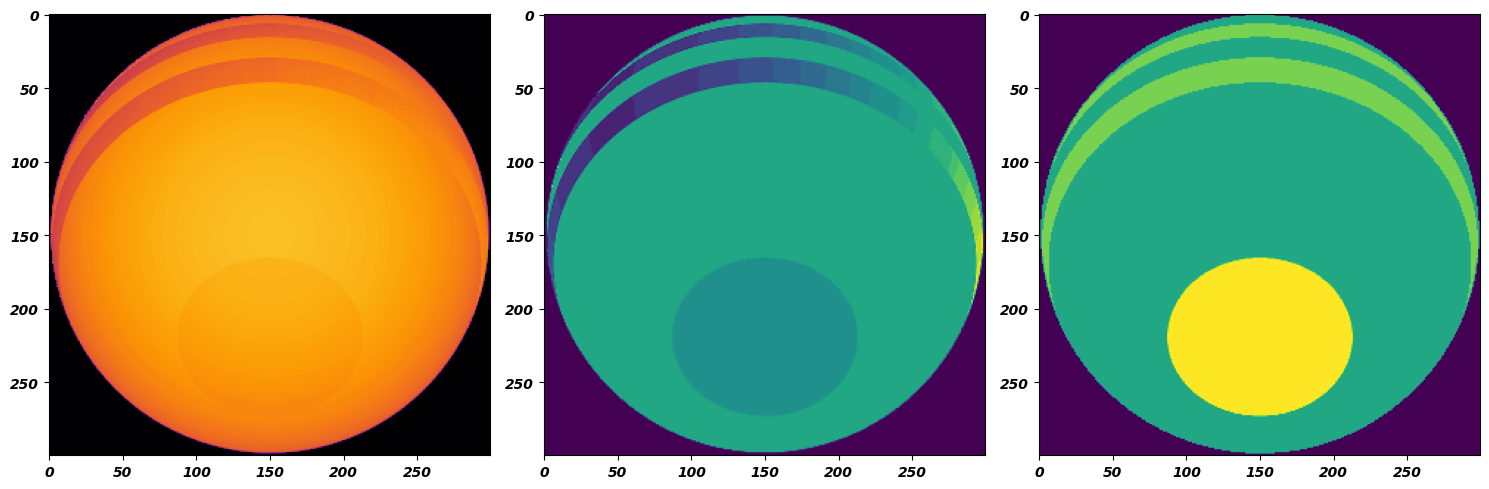

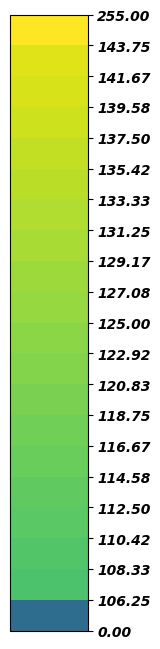

Lightcurve generated in 0.25 seconds.


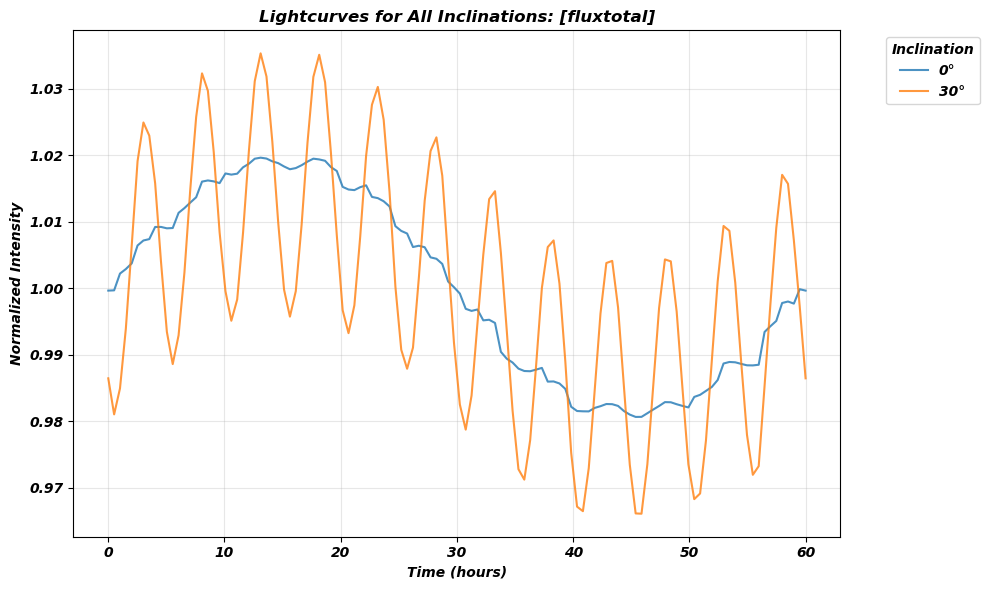

In [4]:
sim_config = {'modu_config': 'polarStatic',
                  'inclinations': [0, 30],
                  'mesh_resolution': 400,
                  'plot_paths': False,
                  'plot_lc': True}

renderer('default_sim', sim_config, vortex_config=True)

Great, we have our first simulation! Here's a breakdown of what we're seeing:

Right now, we've modeled a brown dwarf with various "bands" on its surface, each representing different atmospheric features. We can also see a clear polar region with 5 bright spots (these are our vortices). The output gives us a series of images, each showing the brown dwarf at a different inclination angle. Also, each image has three versions of the brown dwarf; we'll go into more detail on what these mean later.

We also have a lightcurve plot that displays the lightcurve of the brown dwarf at each inclination. Lastly, if we navigate to the right directory, we'll find short animated videos that show the time evolution of the brown dwarf's atmospheric features.

Each simulation run will give us the same outputs:

1. Images of the brown dwarf at our selected inclination angles.
2. Lightcurve plot for all selected inclinations
3. Videos of the time evolution at all selected inclinations

### **Atmosphere Configuration**

Now that we have an idea of what we'll get out of the simulation, we can start messing with the atmosphere settings. The atmosphere consists of two main features: the different regions (band and polar) and the vortices. We'll start by understanding the band configurations.

#### **Bands**

Our last simulation had clearly defined bands along the surface; in the output, some had gradients (band regions), some were solid color (ambient), and the polar regions represented their own feature. Let's see how to edit these properties.

The cell below defines the variables that edit the band properties:

* Brightness (amplitude)
* Variability
* Rotational period

In [3]:
# base amplitudes of polar, band, and ambient regions
Fpolar = 0.98
Fband = 1
Fambient = 1

# variability of polar, band, and ambient regions
Fpolar_var = 0.05
Fband_var = 0.15
Fambient_var = 0.00

# rotational period of brown dwarf
Prot = 5

# organize the above information
amp_config = {'Fpolar': Fpolar,
              'Fband': Fband,
              'Fambient': Fambient,
              'Fpolar_var': Fpolar_var,
              'Fband_var': Fband_var,
              'Fambient_var': Fambient_var,
              'Prot': Prot}

The array in the next cell sets up the actual configuration of bands by combining the previous information and defining the new parameters:

* Latitude boundaries (top and bottom edges of each band)
* Type of region ('B' = band, 'P' = polar)
* Phase (phase offset for the variability of the region)
* Period (period of variation for the region)

This is the default configuration we saw in the basic simulation:

```python
band_config_array = [
    # Format: [lat2, lat1, amplitude, type, phase, period, planet_period, variability]
    [90, 65, Fpolar, 'P', 0, 60, Prot, Fpolar_var],    # North polar cap
    [15, 5, Fband, 'B', 0, 5, Prot, Fband_var],       # Northern band
    [-5, -15, Fband, 'B', 0, 5, Prot, Fband_var],     # Southern band
    [-65, -90, Fpolar, 'P', 0, 60, Prot, Fband_var]   # South polar cap
]
```

What happens if we add a couple bands? Run the cell below to run the simulation with the new configuration.

In [ ]:
band_config_array = [
    # Format: [lat2, lat1, amplitude, type, phase, period, planet_period, variability]
    [90, 65, Fpolar, 'P', 0, 60, Prot, Fpolar_var],
    [50, 30, Fband, 'B', 0, 5, Prot, Fband_var],
    [20, 5, Fband, 'B', 0, 5, Prot, Fband_var],  # NEW BAND
    [-5, -20, Fband, 'B', 0, 5, Prot, Fband_var],  # NEW BAND
    [-30, -50, Fband, 'B', 0, 5, Prot, Fband_var],
    [-65, -90, Fpolar, 'P', 0, 60, Prot, Fband_var]
]

band_config = [amp_config, band_config_array]

renderer('band_sim', sim_config, band_config=band_config, vortex_config=True)

There's 4 bands instead of 2! The number and type of bands can be directly changed by editing the `band_config` array.

***Note**: The size and order of the bands are dictated by the latitude bounds, not their position in the array.*

#### **Variability**

Let's take a look at the videos we've got so far. Each band and polar region has a periodically varying brightness/pattern, and these directly influence our resulting lightcurves.

Let's make some edits to our default configuration and see what that does to our lightcurve.

We previously had 2 bands, both with the same brightness period. Let's try changing the `period` of one band to `20` hours. Then, run the cell to run the simulation.

In [ ]:
band_config_array = [
    # Format: [lat2, lat1, amplitude, type, phase, period, planet_period, variability]
    [90, 65, Fpolar, 'P', 0, 60, Prot, Fpolar_var],
    [15, 5, Fband, 'B', 0, 5, Prot, Fband_var],
    [-5, -15, Fband, 'B', 0, 20, Prot, Fband_var],  # CHANGED PERIOD
    [-65, -90, Fpolar, 'P', 0, 60, Prot, Fband_var]
]

band_config = [amp_config, band_config_array]

renderer('var_band', sim_config, band_config=band_config, vortex_config=True)

That's an interesting pattern! We're seeing multiple periods here for the 45 degree inclination: the 5 hour period and the 20 hour period from the band regions.

What if we edit the period of the polar regions instead?

The array below changes the polar region period to `30` hours. Run the cell to see what kind of lightcurve we get!

In [ ]:
band_config_array = [
    [90, 65, Fpolar, 'P', 0, 30, Prot, Fpolar_var],  # CHANGED PERIOD
    [15, 5, Fband, 'B', 0, 5, Prot, Fband_var],
    [-5, -15, Fband, 'B', 0, 5, Prot, Fband_var],
    [-65, -90, Fpolar, 'P', 0, 30, Prot, Fband_var]  # CHANGED PERIOD
]

band_config = [amp_config, band_config_array]

renderer('var_polar', sim_config, band_config=band_config, vortex_config=True)

We see the expected pattern in the lightcurve: at 0 degrees inclination, our curve has a 30 hour period (as opposed to the original 60 hours)!

Let's try one more modification by changing the phase offset values in the array. This value represents a phase shift in the variability of the region, and we want to understand what it does to our lightcurve.

In the cell below, we add a phase offset of `10` hours to one of our bands so that both bands are no longer fully in phase. Try running the cell!

In [ ]:
band_config_array = [
    [90, 65, Fpolar, 'P', 0, 60, Prot, Fpolar_var],
    [15, 5, Fband, 'B', 10, 5, Prot, Fband_var],  # CHANGED PHASE
    [-5, -15, Fband, 'B', 0, 5, Prot, Fband_var],
    [-65, -90, Fpolar, 'P', 0, 60, Prot, Fband_var]
]

band_config = [amp_config, band_config_array]

renderer('var_phase', sim_config, band_config=band_config, vortex_config=True)

### **Vortices**

The other, significant aspect of atmospheres in this simulation are the vortices!

There are two cases that this simulation handles:
* `polarStatic`:
    - all vortices vary in phase with each other and the polar background
* `polarDynamic`:
    - each vortex has its own phase offset

Our default simulation runs the `polarStatic` case; we'll deal with the phase offsets later in this notebook.

The vortex properties are stored in a list (shown in the cell below), and we can edit these values directly to make changes to our simulation. Our primary properties are:

* Number of vortices
* Size of the vortices
* Latitude position of the vortices
* Base amplitude of the vortices
* Vortex drift

The default configuration looks like this:

```python
n_vortice = 5  # number of vortices
radius_frac = 0.0075  # size of vortex as a fraction of polar region area
centerLat = 80  # latitude position of the vortices
ampVortex = 0.15  # base amplitude of vortices in vortex/polar cap unit at time t
drift = True  # whether the vortex drifts

vortex_config = [n_vortice, radius_frac, drift, centerLat, ampVortex]
```

Let's try a simulation with only 3 vortices and see if we can make them slightly smaller. Run the cell below to try this configuration!

In [ ]:
n_vortice = 3
radius_frac = 0.0025
centerLat = 80
ampVortex = 0.15
drift = True

vortex_config = [n_vortice, radius_frac, drift, centerLat, ampVortex]

renderer('vortex_var1', sim_config, band_config=band_config, vortex_config=vortex_config)

That worked! Sure, the vortices are a little small at the moment, but they illustrate the purpose of the parameter.

Now, let's try moving them closer together. This simulation generates equidistant vortices (longitudinally) along a central latitude. We can move the vortices closer together by moving all of them closer to the pole (increasing the central latitude). Let's try that in the next cell.

In [ ]:
centerLat = 85

vortex_config = [n_vortice, radius_frac, drift, centerLat, ampVortex]

renderer('vortex_var2', sim_config, band_config=band_config, vortex_config=vortex_config)

Let's say we want to make sure the vortices don't move over time. We can turn the vortex drift off easily by setting:

```python
drift = False
```

In [ ]:
drift = False

renderer('no_drift', sim_config, band_config=band_config, vortex_config=vortex_config)

#### **polarDynamic**

If you look at the current output videos, you'll notice that all the vortices vary in phase and are always slightly brighter than their background. This behavior defines our `polarStatic` case.

The `polarDynamic` case allows you to add individual phase offsets for each of the vortices. To do that, we create a `phase_offsets` array where each value in the array corresponds to one vortex.

```python
phase_offsets = [phase1, phase2, phase3]
```

Run the cell below to try the `polarDynamic` case!

VTK Version: 9.5.0
OpenGL2 Enabled: True
Drift angles shape: (3, 120)
Sample angles: [0.80783041 3.13705533 3.77932564 0.18025836 0.929447  ]
Simulation completed in 18.53 seconds.
Creating 2 videos using 4 workers...


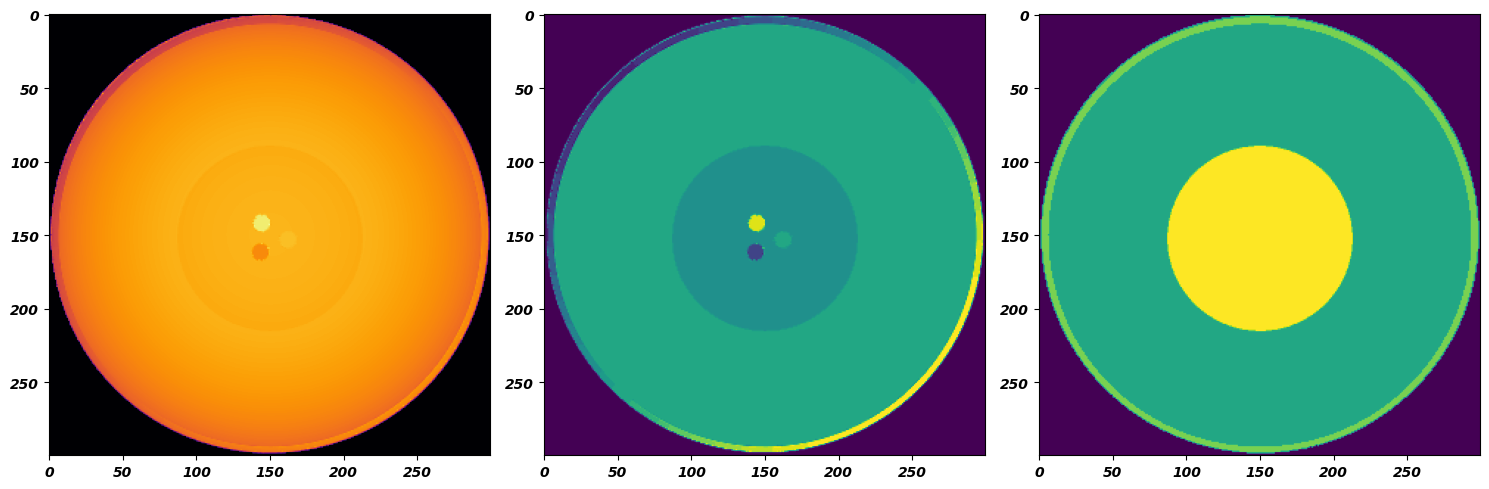

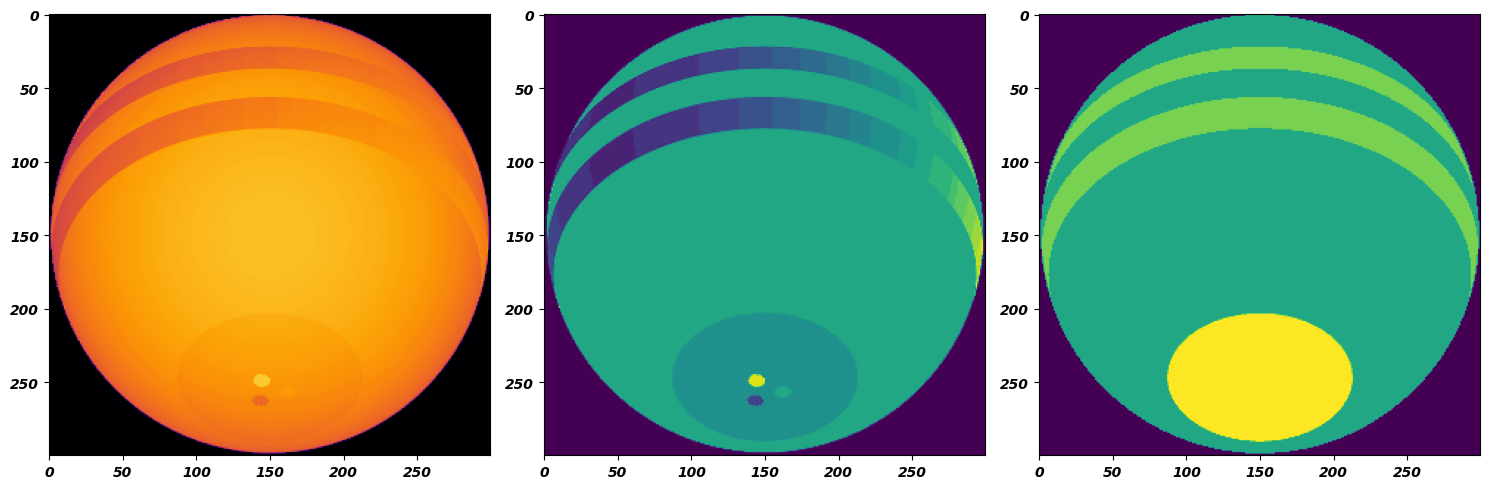

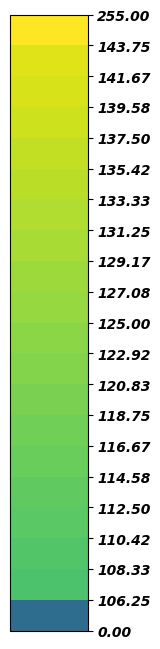

Lightcurve generated in 0.11 seconds.


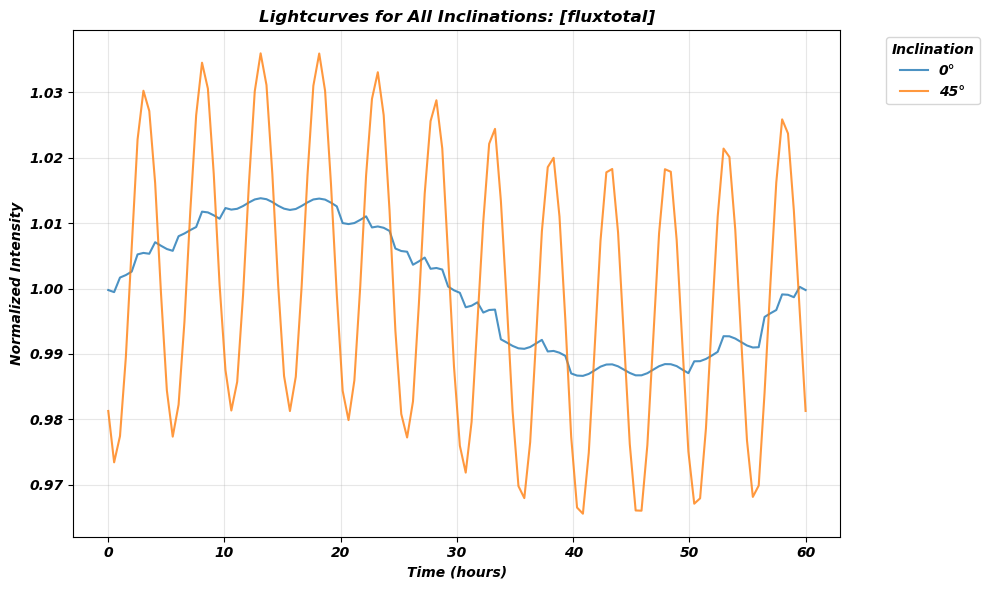

In [11]:
phase_values = [3.0, 1.0, 7.0]  # list size should match the number of vortices!

sim_config = {'modu_config': 'polarDynamic',
                  'inclinations': [0, 45],
                  'mesh_resolution': 400,
                  'plot_paths': False,
                  'plot_lc': True}

renderer('dynamic_sim', sim_config, vortex_config=vortex_config, phase_values=phase_values)

### **Time Configuration**

The last few settings to take into consideration are related to the time span of the simulation itself. `time_config` allows you to edit the following simulation parameters:

* `t0`: start time (hours)
* `t1`: end time (hours)
* `frames`: number of frames for the simulation

The format is the following:

```python
time_config = [t0, t1, frames, option]
```

Try running the cell below to see what a shorter simulation looks like.

VTK Version: 9.5.0
OpenGL2 Enabled: True
Drift angles shape: (5, 120)
Sample angles: [0.80783041 3.13705533 3.77932564 0.18025836 0.929447  ]
Simulation completed in 167.98 seconds.
Creating 2 videos using 4 workers...


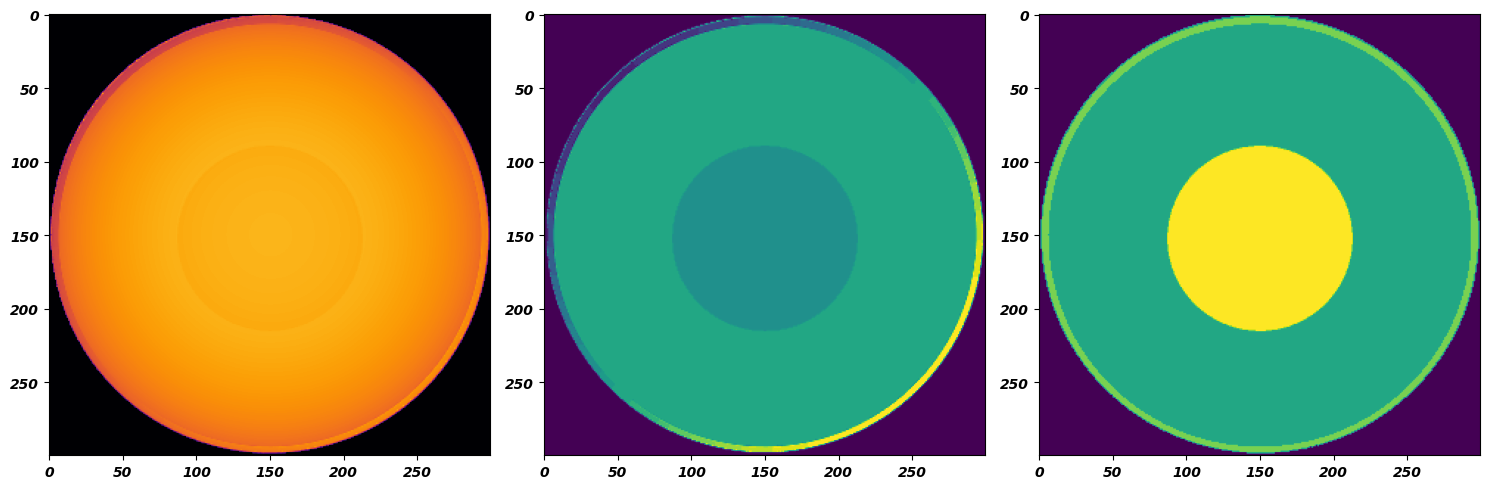

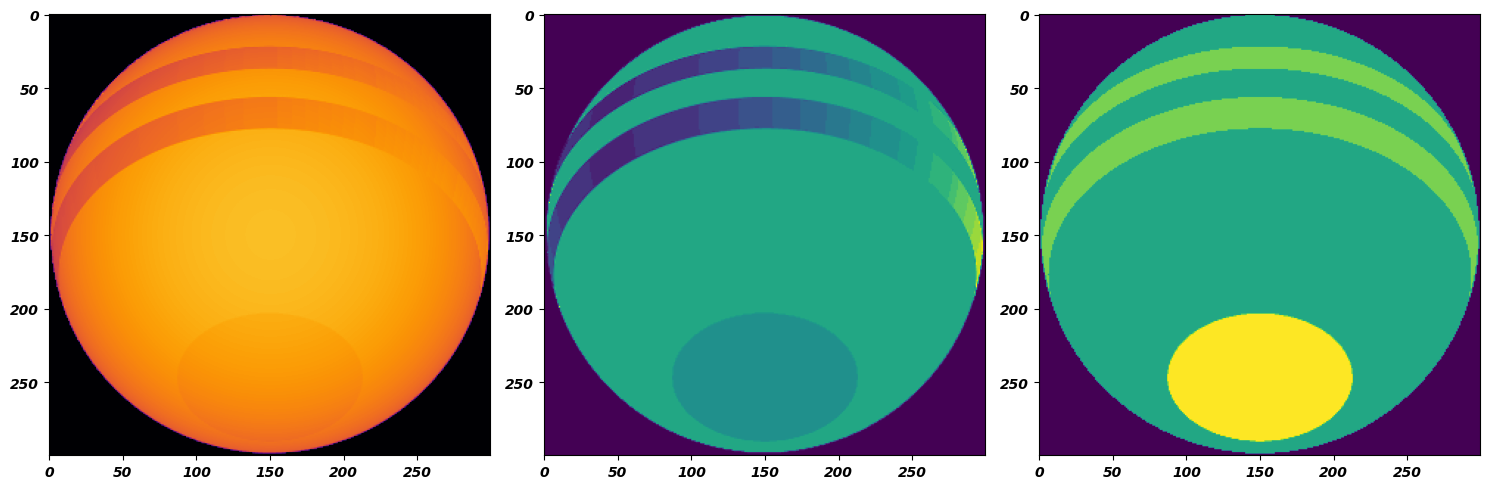

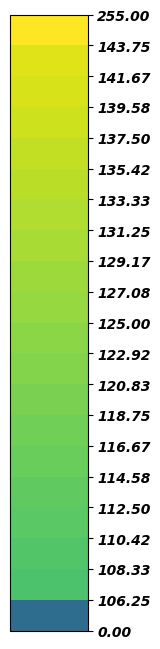

Lightcurve generated in 0.12 seconds.


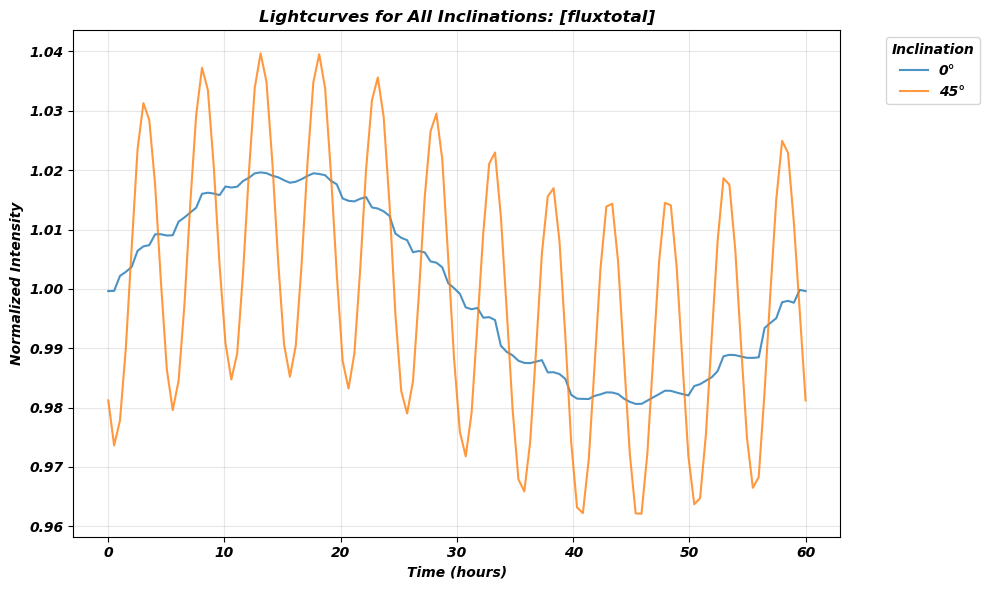

In [12]:
time_config = [0, 30, 60, 'full']

sim_config = {'modu_config': 'polarStatic',
                  'inclinations': [0, 45],
                  'mesh_resolution': 400,
                  'plot_paths': False,
                  'plot_lc': True}

renderer('time_sim', sim_config, vortex_config=True)

### **Summary**

Perfect! You should now have a basic idea of how to work this simulation and what the different parameters do. Here's an overview of what we've covered so far:

1. **Setup**
    - Find and input main.py directory
    - Import `renderer()`

2. **Running a Basic Simulation**
    - Running `renderer()` with only `sim_config` runs a simulation with default settings

3. **Atmosphere Configuration: Bands**
    - Can change number, size, location, and type of bands by editing `band_config` array
    - Can change brightness and variability of regions by editing `amp_config` dictionary

4. **Atmosphere Configuration: Vortices**
    - Can change number, size, latitude, amplitude, and variability of vortices
    - Two modes:
        - `polarStatic` = all vortices vary in phase
        - `polarDynamic` = vortices have different phase offsets

5. **Time Configuration**
    - Can change start and end times and number of frames for the simulation